🚁 MADDS SIMULATION STARTED (Hybrid Multi-Agent Drone System)

  🧠 Drone 1: Planning optimal path to (18, 18)...
  ✅ Drone 1: Path found with 20 steps | Battery cost ~24.0%
  🧠 Drone 2: Planning optimal path to (3, 17)...
  ✅ Drone 2: Path found with 16 steps | Battery cost ~19.2%
  🧠 Drone 3: Planning optimal path to (17, 5)...
  ✅ Drone 3: Path found with 18 steps | Battery cost ~21.6%
Drone 1 reached delivery point (18, 18)
Drone 2 reached delivery point (3, 17)
Drone 3 reached delivery point (17, 5)

🌧️  WEATHER DISTURBANCE: Sudden rain + wind on Drone 1!
  🚨 Drone 1: Strong wind detected! Activating stability mode.

🔄 RESCHEDULING TRIGGERED for package (18, 18) (Drone 1 delayed)
  📡 Drone 2 bids: 21 (ETA=16, Battery=80.8%)
  📡 Drone 3 bids: 23 (ETA=18, Battery=78.4%)
🏆 WINNER: Drone 2 takes over the delivery!
  🧠 Drone 2: Planning optimal path to (18, 18)...
  ✅ Drone 2: Path found with 16 steps | Battery cost ~19.2%

✅ SIMULATION COMPLETE!
Drone 1 | Final Battery: 59.0% | Position

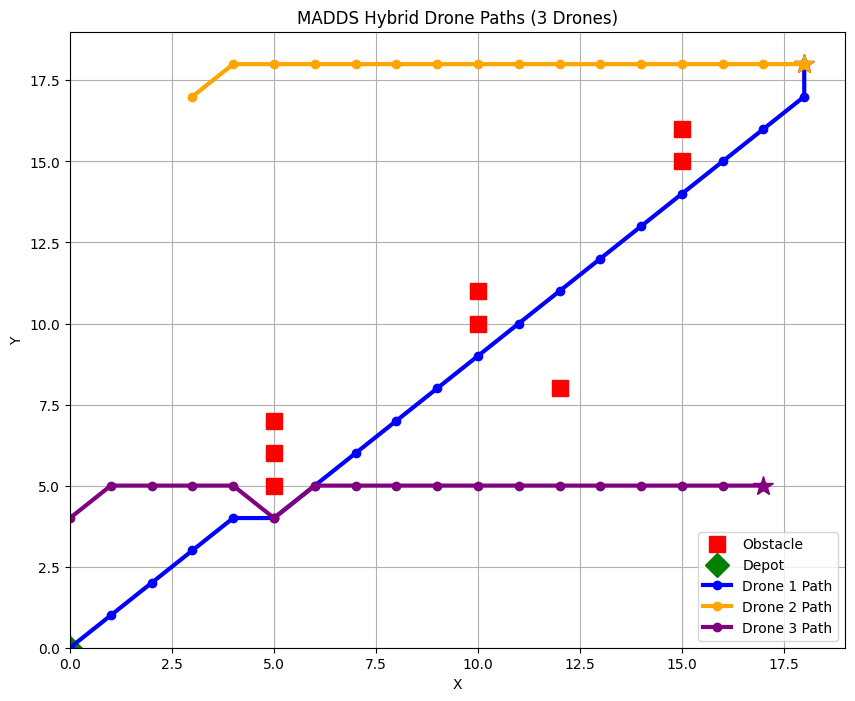

In [1]:
# MADDS - Multi-Agent Drone Delivery System Simulation
# Hybrid Agent Architecture (Reactive + Deliberative + Social)
# For Assignment 3 - Run this in Google Colab / Jupyter Notebook

import matplotlib.pyplot as plt
from queue import PriorityQueue
import random
import time

# ====================== GRID MAP (Urban Environment) ======================
class UrbanGrid:
    def __init__(self):
        self.width = 20
        self.height = 20
        self.obstacles = [(5,5),(5,6),(5,7),(10,10),(10,11),(12,8),(15,15),(15,16)]
        self.depot = (0, 0)
        self.delivery_points = [(18,18), (3,17), (17,5)]
    
    def is_valid(self, x, y):
        return 0 <= x < self.width and 0 <= y < self.height and (x,y) not in self.obstacles

# ====================== ENERGY-AWARE A* (Deliberative Layer) ======================
def energy_aware_astar(grid, start, goal, wind_factor=1.0, payload=1):
    open_set = PriorityQueue()
    open_set.put((0, start))
    came_from = {}
    g_score = {start: 0}
    f_score = {start: heuristic(start, goal)}
    
    while not open_set.empty():
        current = open_set.get()[1]
        if current == goal:
            return reconstruct_path(came_from, current)
        
        for dx, dy in [(-1,0),(1,0),(0,-1),(0,1),(-1,-1),(-1,1),(1,-1),(1,1)]:
            neighbor = (current[0] + dx, current[1] + dy)
            if not grid.is_valid(*neighbor):
                continue
            tentative_g = g_score[current] + 1 * (1 + wind_factor * 0.4 + payload * 0.2)
            if tentative_g < g_score.get(neighbor, float('inf')):
                came_from[neighbor] = current
                g_score[neighbor] = tentative_g
                f_score[neighbor] = tentative_g + heuristic(neighbor, goal)
                open_set.put((f_score[neighbor], neighbor))
    return None

def heuristic(a, b):
    return abs(a[0] - b[0]) + abs(a[1] - b[1])

def reconstruct_path(came_from, current):
    path = [current]
    while current in came_from:
        current = came_from[current]
        path.append(current)
    return path[::-1]

# ====================== HYBRID DRONE AGENT ======================
class HybridDrone:
    def __init__(self, drone_id, start_pos):
        self.id = drone_id
        self.position = start_pos
        self.battery = 100.0
        self.path = []
        self.current_task = None
        self.reactive_mode = False
    
    def reactive_layer(self, grid, wind_speed):
        """Safety-first reactive behavior (runs instantly)"""
        if wind_speed > 12:
            print(f"  🚨 Drone {self.id}: Strong wind detected! Activating stability mode.")
            self.reactive_mode = True
            self.battery -= 5
        # Simple obstacle check (in real system = LIDAR)
        for obs in [(self.position[0]+1,self.position[1]), (self.position[0]-1,self.position[1])]:
            if obs in grid.obstacles:
                print(f"  🛑 Drone {self.id}: Obstacle ahead! Emergency hover.")
                self.reactive_mode = True
    
    def deliberative_layer(self, grid, goal, wind_factor, payload):
        """BDI Planner - Energy-aware path"""
        print(f"  🧠 Drone {self.id}: Planning optimal path to {goal}...")
        self.path = energy_aware_astar(grid, self.position, goal, wind_factor, payload)
        if self.path:
            print(f"  ✅ Drone {self.id}: Path found with {len(self.path)} steps | Battery cost ~{len(self.path)*1.2:.1f}%")
            self.battery -= len(self.path) * 1.2
        else:
            print(f"  ❌ Drone {self.id}: No path found!")
    
    def social_layer(self, package, other_drones):
        """Contract-Net Bid"""
        eta = len(self.path) if self.path else 999
        battery_cost = 15 if self.battery < 30 else 5
        bid = eta + battery_cost
        print(f"  📡 Drone {self.id} bids: {bid} (ETA={eta}, Battery={self.battery:.1f}%)")
        return bid

# ====================== CONTRACT-NET RESCHEDULING ======================
def contract_net_reschedule(delayed_drone, package, all_drones, grid):
    print(f"\n🔄 RESCHEDULING TRIGGERED for package {package} (Drone {delayed_drone.id} delayed)")
    bids = []
    for drone in all_drones:
        if drone.id != delayed_drone.id:
            bid_value = drone.social_layer(package, all_drones)
            bids.append((drone, bid_value))
    
    winner = min(bids, key=lambda x: x[1])[0]
    print(f"🏆 WINNER: Drone {winner.id} takes over the delivery!")
    winner.deliberative_layer(grid, package, wind_factor=1.2 if random.random()>0.5 else 0.8, payload=2)
    return winner

# ====================== MAIN SIMULATION ======================
def run_simulation():
    print("🚁 MADDS SIMULATION STARTED (Hybrid Multi-Agent Drone System)\n")
    grid = UrbanGrid()
    drones = [
        HybridDrone(1, (0, 0)),
        HybridDrone(2, (0, 2)),
        HybridDrone(3, (0, 4))
    ]
    
    packages = [(18,18), (3,17), (17,5)]
    
    # Assign initial tasks
    for i, drone in enumerate(drones):
        drone.current_task = packages[i]
        drone.deliberative_layer(grid, packages[i], wind_factor=0.5, payload=1)
        drone.reactive_layer(grid, wind_speed=8)
    
    # Simulate flight (print progress)
    for drone in drones:
        if drone.path:
            drone.position = drone.path[-1]
            print(f"Drone {drone.id} reached delivery point {drone.position}")
    
    # Introduce disturbance
    print("\n🌧️  WEATHER DISTURBANCE: Sudden rain + wind on Drone 1!")
    drones[0].reactive_layer(grid, wind_speed=18)
    drones[0].battery -= 12  # delay
    
    # Dynamic rescheduling
    winner = contract_net_reschedule(drones[0], packages[0], drones, grid)
    
    # Final positions
    print("\n✅ SIMULATION COMPLETE!")
    for d in drones:
        print(f"Drone {d.id} | Final Battery: {d.battery:.1f}% | Position: {d.position}")
    
    # ====================== VISUALIZATION ======================
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.set_xlim(0, 19)
    ax.set_ylim(0, 19)
    ax.set_title("MADDS Hybrid Drone Paths (3 Drones)")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    
    # Plot grid & obstacles
    for obs in grid.obstacles:
        ax.plot(obs[0], obs[1], 's', color='red', markersize=12, label='Obstacle' if obs==(5,5) else "")
    ax.plot(grid.depot[0], grid.depot[1], 'D', color='green', markersize=12, label='Depot')
    
    colors = ['blue', 'orange', 'purple']
    for i, drone in enumerate(drones):
        if drone.path:
            xs, ys = zip(*drone.path)
            ax.plot(xs, ys, 'o-', color=colors[i], linewidth=3, label=f'Drone {drone.id} Path')
            ax.plot(xs[-1], ys[-1], '*', color=colors[i], markersize=15)
    
    ax.legend()
    plt.grid(True)
    plt.show()

# ====================== RUN THE SIMULATION ======================
if __name__ == "__main__":
    run_simulation()